In [124]:
import numpy 
import pandas
import matplotlib.pyplot as plt
import matplotlib
import scipy
import glob
import seaborn
from scipy.optimize import curve_fit
import itertools

# ML
# import sklearn

pandas.set_option('display.max_columns', None)

### Import

In [125]:
def ImportDataframe(
    PATH,
    FILENAME,
    FILEVARS
):

    df = pandas.read_csv(
        PATH + FILENAME,
        delimiter = "\t", 
        names = FILEVARS, 
        index_col = False
    )

    return df

In [126]:
VARS_WBDT = ["source", "run", "event", "islc",
    "linfitlen", "linfitdiff", "linfitgaplen", "linfitrms",
    "vtxdist", "pca2ratio", "pca3ratio", "openanglediff", 
    "chgfracspread", "chgendfrac", "halototratio", "concentration", "conicalness",
    "trackscore", "istrack", "pdg", "parentpdg", 
    "dirxtruth", "dirytruth", "dirztruth", "dirxztruth", "diryztruth",
    "hitcomp", "ecomp", "hitpur", "epur",
    "start_vstruth", "startendenergy", 
    "nhits0truth", "nhits1truth", "nhits2truth",
    "nhits0", "nhits1", "nhits2",
    "shwopenangle", "shwconvgap", "shwcolldedx", "shwlen",
    "vtxx", "vtxy", "vtxz", "vtxxtruth", "vtxytruth", "vtxztruth",
    "vtx_vstruth", "isinFV", "truthindex", "iscc", "nupdg"
]

In [127]:
VARS = ["source", "run", "event", "islc",
        "trackscore", "istrack", "pdg", "parentpdg", 
        "dirxtruth", "dirytruth", "dirztruth", "dirxztruth", "diryztruth",
        "hitcomp", "ecomp", "hitpur", "epur",
        "start_vstruth", "startendenergy", 
        "nhits0truth", "nhits1truth", "nhits2truth",
        "nhits0", "nhits1", "nhits2",
        "shwopenangle", "shwconvgap", "shwcolldedx", "shwlen",
        "vtxx", "vtxy", "vtxz", "vtxxtruth", "vtxytruth", "vtxztruth",
        "vtx_vstruth", "isinFV", "truthindex", "iscc", "nupdg"
]

#### December 2025 validations

In [ ]:
FILEPATH = "/exp/icarus/app/users/msotgia/analysis/twoDRecoStudies/showerValidations/V10Validation/202605/"

Data_baseline = ImportDataframe(FILEPATH, "2D_DNN_baseline.txt", VARS_WBDT)
Data_1uNp = ImportDataframe(FILEPATH, "2D_DNN_1uNpMpi0_noPulses.txt", VARS_WBDT)
Data_1eNp0pi0 = ImportDataframe(FILEPATH, "2D_DNN_1eNp0pi0_noPulses.txt", VARS_WBDT)
Data_1eNpMpi0 = ImportDataframe(FILEPATH, "2D_DNN_1eNpMpi0_noPulses.txt", VARS_WBDT)

Data_1uNp_v4 = ImportDataframe(FILEPATH, "V4_1uNp.txt", VARS_WBDT)
Data_1eNp_V4 = ImportDataframe(FILEPATH, "V4_1eNp.txt", VARS_WBDT)

#### Spring production-era tests

In [111]:
FILEPATH = "/exp/icarus/app/users/rtriozzi/sbnana/TestWirecell/"

### standard 2D signal processing
Data = pandas.read_csv(
    FILEPATH + "V10Validation_mcnu2D-remc-nue-wcluster3d_wpulsetrain.txt",
    delimiter = "\t", 
    names = Vars, 
    index_col = False
)

# NO pulse trains
Data_NPP = pandas.read_csv(
    FILEPATH + "V10Validation_mcnu2D-remc-nue-wcluster3d_nopulsetrain.txt",
    delimiter = "\t", 
    names = Vars, 
    index_col = False
)

### without DNN-ROI
Data_noDNN = pandas.read_csv(
    FILEPATH + "V10Validation_mcnu2D-remc-nue-wcluster3d_noDNN_wpulsetrain.txt",
    delimiter = "\t", 
    names = Vars, 
    index_col = False
)

# NO pulse trains
Data_noDNN_NPP = pandas.read_csv(
    FILEPATH + "V10Validation_mcnu2D-remc-nue-wcluster3d_noDNN_nopulsetrain.txt",
    delimiter = "\t", 
    names = Vars, 
    index_col = False
)

## Pulse train investigation

### Aggregated

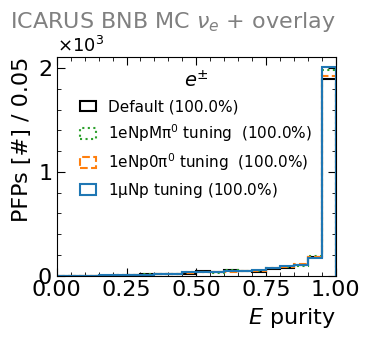

In [ ]:
fig, ax = plt.subplots(figsize=(4., 3.5), ncols=1, layout='tight')

Var = 'epur'
VarName = '$E$ purity'
width = 0.05; binning = numpy.arange(0, 1+width, width)
PDGPrintName = 'e'
PDGName = '$e^{\\pm}$'
PDG = 11

DataToPlot = Data_baseline
Mask = (DataToPlot.startendenergy > 0.05) & (abs(DataToPlot.pdg) == PDG) & (DataToPlot.nhits2 > 10) & (DataToPlot.isinFV)
ax.hist(DataToPlot[Mask][Var], bins=binning, histtype='step', lw=1.5, ec='black', label=f'Default ({100*numpy.median(DataToPlot[Mask][Var]):.1f}%)', density=False)

DataToPlot = Data_1eNpMpi0
Mask = (DataToPlot.startendenergy > 0.05) & (abs(DataToPlot.pdg) == PDG) & (DataToPlot.nhits2 > 10) & (DataToPlot.isinFV)
ax.hist(DataToPlot[Mask][Var], bins=binning, histtype='step', lw=1.5, ls=':', ec='C2', label=f'$\\mathrm{{1e N p M \\pi^0}}$ tuning  ({100*numpy.median(DataToPlot[Mask][Var]):.1f}%)', density=False)

DataToPlot = Data_1eNp0pi0
Mask = (DataToPlot.startendenergy > 0.05) & (abs(DataToPlot.pdg) == PDG) & (DataToPlot.nhits2 > 10) & (DataToPlot.isinFV)
ax.hist(DataToPlot[Mask][Var], bins=binning, histtype='step', lw=1.5, ec='C1', ls='--', label=f'$\\mathrm{{1e N p 0 \\pi^0}}$ tuning  ({100*numpy.median(DataToPlot[Mask][Var]):.1f}%)', density=False)

DataToPlot = Data_1uNp
Mask = (DataToPlot.startendenergy > 0.05) & (abs(DataToPlot.pdg) == PDG) & (DataToPlot.nhits2 > 10) & (DataToPlot.isinFV)
ax.hist(DataToPlot[Mask][Var], bins=binning, histtype='step', lw=1.5, ec='C0', label=f'$\\mathrm{{1\\mu N p}}$ tuning ({100*numpy.median(DataToPlot[Mask][Var]):.1f}%)', density=False)

DataToPlot = Data_1uNp_v4
Mask = (DataToPlot.startendenergy > 0.05) & (abs(DataToPlot.pdg) == PDG) & (DataToPlot.nhits2 > 10) & (DataToPlot.isinFV)
ax.hist(DataToPlot[Mask][Var], bins=binning, histtype='step', lw=3, ec='darkblue', label=f'$\\mathrm{{1\\mu N p}}$ tuning (metric 4, {100*numpy.median(DataToPlot[Mask][Var]):.1f}%)', density=False)

DataToPlot = Data_1eNp_V4
Mask = (DataToPlot.startendenergy > 0.05) & (abs(DataToPlot.pdg) == PDG) & (DataToPlot.nhits2 > 10) & (DataToPlot.isinFV)
ax.hist(DataToPlot[Mask][Var], bins=binning, histtype='step', lw=3, ec='red', ls=':', label=f'$\\mathrm{{1e N p}}$ tuning (metric 4, {100*numpy.median(DataToPlot[Mask][Var]):.1f}%)', density=False)

# labels
ax.set_title("ICARUS BNB MC $\\nu_e$ + overlay", fontsize=16, loc='right', color='gray')
ax.set_xlabel(VarName, fontsize=16, loc='right')
ax.set_ylabel(f"PFPs [#] / {binning[1]-binning[0]:g}", fontsize=16, loc='top')
leg = ax.legend(frameon=False, fancybox=False, fontsize=11., ncol=1, loc='upper center', handlelength=1, columnspacing=1, title=PDGName)
leg.get_title().set_fontsize('14')
                
# ticks
ax.tick_params(labelsize=16, length=6, direction='in', right=True, top=True)
ax.tick_params(which='minor', length=3, direction='in', right=True, top=True)
ax.ticklabel_format(style='scientific', axis='y', scilimits=(0,0), useMathText=True)
ax.yaxis.offsetText.set_fontsize(13)
ax.minorticks_on()
ax.set_xlim(binning[0], binning[-1])
#ax.set_yscale('log')

plt.show()
fig.savefig(
    f"/exp/icarus/app/users/msotgia/analysis/twoDRecoStudies/showerValidations/V10Validation/202605/plots/NuE_AllFlavors_{PDGPrintName}_{Var}.png", 
    bbox_inches='tight', dpi=300)

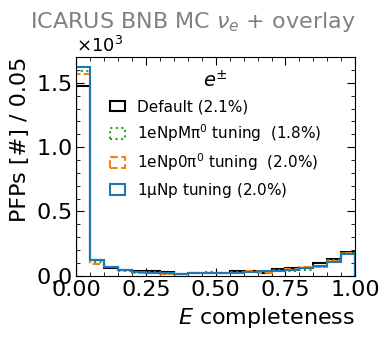

In [7]:
fig, ax = plt.subplots(figsize=(4., 3.5), ncols=1, layout='tight')

Var = 'ecomp'
VarName = '$E$ completeness'
width = 0.05; binning = numpy.arange(0, 1+width, width)
PDGPrintName = 'e'
PDGName = '$e^{\\pm}$'
PDG = 11

DataToPlot = Data_baseline
Mask = (DataToPlot.startendenergy > 0.05) & (abs(DataToPlot.pdg) == PDG) & (DataToPlot.nhits2 > 10) & (DataToPlot.isinFV)
ax.hist(DataToPlot[Mask][Var], bins=binning, histtype='step', lw=1.5, ec='black', label=f'Default ({100*numpy.median(DataToPlot[Mask][Var]):.1f}%)', density=False)

DataToPlot = Data_1eNpMpi0
Mask = (DataToPlot.startendenergy > 0.05) & (abs(DataToPlot.pdg) == PDG) & (DataToPlot.nhits2 > 10) & (DataToPlot.isinFV)
ax.hist(DataToPlot[Mask][Var], bins=binning, histtype='step', lw=1.5, ls=':', ec='C2', label=f'$\\mathrm{{1e N p M \\pi^0}}$ tuning  ({100*numpy.median(DataToPlot[Mask][Var]):.1f}%)', density=False)

DataToPlot = Data_1eNp0pi0
Mask = (DataToPlot.startendenergy > 0.05) & (abs(DataToPlot.pdg) == PDG) & (DataToPlot.nhits2 > 10) & (DataToPlot.isinFV)
ax.hist(DataToPlot[Mask][Var], bins=binning, histtype='step', lw=1.5, ec='C1', ls='--', label=f'$\\mathrm{{1e N p 0 \\pi^0}}$ tuning  ({100*numpy.median(DataToPlot[Mask][Var]):.1f}%)', density=False)

DataToPlot = Data_1uNp
Mask = (DataToPlot.startendenergy > 0.05) & (abs(DataToPlot.pdg) == PDG) & (DataToPlot.nhits2 > 10) & (DataToPlot.isinFV)
ax.hist(DataToPlot[Mask][Var], bins=binning, histtype='step', lw=1.5, ec='C0', label=f'$\\mathrm{{1\\mu N p}}$ tuning ({100*numpy.median(DataToPlot[Mask][Var]):.1f}%)', density=False)

# labels
ax.set_title("ICARUS BNB MC $\\nu_e$ + overlay", fontsize=16, loc='right', color='gray')
ax.set_xlabel(VarName, fontsize=16, loc='right')
ax.set_ylabel(f"PFPs [#] / {binning[1]-binning[0]:g}", fontsize=16, loc='top')
leg = ax.legend(frameon=False, fancybox=False, fontsize=11., ncol=1, loc='upper center', handlelength=1, columnspacing=1, title=PDGName)
leg.get_title().set_fontsize('14')
                
# ticks
ax.tick_params(labelsize=16, length=6, direction='in', right=True, top=True)
ax.tick_params(which='minor', length=3, direction='in', right=True, top=True)
ax.ticklabel_format(style='scientific', axis='y', scilimits=(0,0), useMathText=True)
ax.yaxis.offsetText.set_fontsize(13)
ax.minorticks_on()
ax.set_xlim(binning[0], binning[-1])
#ax.set_yscale('log')

plt.show()
fig.savefig(
    f"/exp/icarus/app/users/msotgia/analysis/twoDRecoStudies/showerValidations/V10Validation/202605/plots/NuE_AllFlavors_{PDGPrintName}_{Var}.png", 
    bbox_inches='tight', dpi=300)

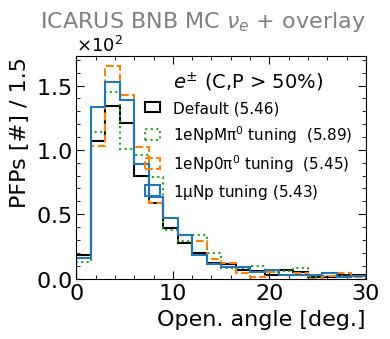

In [8]:
fig, ax = plt.subplots(figsize=(4., 3.5), ncols=1, layout='tight')

Var = 'shwopenangle'
VarName = 'Open. angle [deg.]'
width = 1.5; binning = numpy.arange(0, 30+width, width)
PDGPrintName = 'e'
PDGName = '$e^{\\pm}$'
PDG = 11


DataToPlot = Data_baseline
Mask = (DataToPlot.startendenergy > 0.05) & (abs(DataToPlot.pdg) == PDG) & (DataToPlot.isinFV) & (DataToPlot.hitcomp > 0.5) & (DataToPlot.hitpur > 0.5)
ax.hist(DataToPlot[Mask][Var], bins=binning, histtype='step', lw=1.5, ec='black', label=f'Default ({numpy.median(DataToPlot[Mask][Var]):.2f})', density=False)

DataToPlot = Data_1eNpMpi0
Mask = (DataToPlot.startendenergy > 0.05) & (abs(DataToPlot.pdg) == PDG) & (DataToPlot.isinFV) & (DataToPlot.hitcomp > 0.5) & (DataToPlot.hitpur > 0.5)
ax.hist(DataToPlot[Mask][Var], bins=binning, histtype='step', lw=1.5, ls=':', ec='C2', label=f'$\\mathrm{{1e N p M \\pi^0}}$ tuning  ({numpy.median(DataToPlot[Mask][Var]):.2f})', density=False)

DataToPlot = Data_1eNp0pi0
Mask = (DataToPlot.startendenergy > 0.05) & (abs(DataToPlot.pdg) == PDG) & (DataToPlot.isinFV) & (DataToPlot.hitcomp > 0.5) & (DataToPlot.hitpur > 0.5)
ax.hist(DataToPlot[Mask][Var], bins=binning, histtype='step', lw=1.5, ec='C1', ls='--', label=f'$\\mathrm{{1e N p 0 \\pi^0}}$ tuning  ({numpy.median(DataToPlot[Mask][Var]):.2f})', density=False)

DataToPlot = Data_1uNp
Mask = (DataToPlot.startendenergy > 0.05) & (abs(DataToPlot.pdg) == PDG) & (DataToPlot.isinFV) & (DataToPlot.hitcomp > 0.5) & (DataToPlot.hitpur > 0.5)
ax.hist(DataToPlot[Mask][Var], bins=binning, histtype='step', lw=1.5, ec='C0', label=f'$\\mathrm{{1\\mu N p}}$ tuning ({numpy.median(DataToPlot[Mask][Var]):.2f})', density=False)

# labels
ax.set_title("ICARUS BNB MC $\\nu_e$ + overlay", fontsize=16, loc='right', color='gray')
ax.set_xlabel(VarName, fontsize=16, loc='right')
ax.set_ylabel(f"PFPs [#] / {binning[1]-binning[0]:g}", fontsize=16, loc='top')
leg = ax.legend(frameon=False, fancybox=False, fontsize=11., ncol=1, loc='upper right', handlelength=1, columnspacing=1, title=f'{PDGName} (C,P > 50%)')
leg.get_title().set_fontsize('14')
                
# ticks
ax.tick_params(labelsize=16, length=6, direction='in', right=True, top=True)
ax.tick_params(which='minor', length=3, direction='in', right=True, top=True)
ax.ticklabel_format(style='scientific', axis='y', scilimits=(0,0), useMathText=True)
ax.yaxis.offsetText.set_fontsize(13)
ax.minorticks_on()
ax.set_xlim(binning[0], binning[-1])
#ax.set_yscale('log')

plt.show()
fig.savefig(
    f"/exp/icarus/app/users/msotgia/analysis/twoDRecoStudies/showerValidations/V10Validation/202605/plots/NuE_AllFlavors_{PDGPrintName}_{Var}.png", 
    bbox_inches='tight', dpi=300)


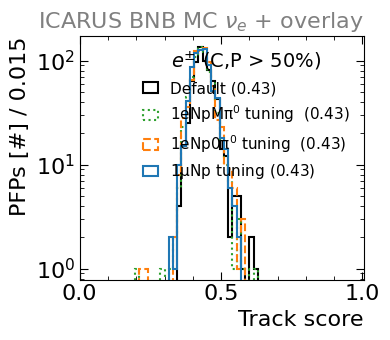

In [14]:
fig, ax = plt.subplots(figsize=(4., 3.5), ncols=1, layout='tight')

Var = 'trackscore'
VarName = 'Track score'
width = 0.015; binning = numpy.arange(0, 1+width, width)
PDGPrintName = 'e'
PDGName = '$e^{\\pm}$'
PDG = 11


DataToPlot = Data_baseline
Mask = (DataToPlot.startendenergy > 0.05) & (abs(DataToPlot.pdg) == PDG) & (DataToPlot.isinFV) & (DataToPlot.hitcomp > 0.5) & (DataToPlot.hitpur > 0.5)
ax.hist(DataToPlot[Mask][Var], bins=binning, histtype='step', lw=1.5, ec='black', label=f'Default ({numpy.median(DataToPlot[Mask][Var]):.2f})', density=False)

DataToPlot = Data_1eNpMpi0
Mask = (DataToPlot.startendenergy > 0.05) & (abs(DataToPlot.pdg) == PDG) & (DataToPlot.isinFV) & (DataToPlot.hitcomp > 0.5) & (DataToPlot.hitpur > 0.5)
ax.hist(DataToPlot[Mask][Var], bins=binning, histtype='step', lw=1.5, ls=':', ec='C2', label=f'$\\mathrm{{1e N p M \\pi^0}}$ tuning  ({numpy.median(DataToPlot[Mask][Var]):.2f})', density=False)

DataToPlot = Data_1eNp0pi0
Mask = (DataToPlot.startendenergy > 0.05) & (abs(DataToPlot.pdg) == PDG) & (DataToPlot.isinFV) & (DataToPlot.hitcomp > 0.5) & (DataToPlot.hitpur > 0.5)
ax.hist(DataToPlot[Mask][Var], bins=binning, histtype='step', lw=1.5, ec='C1', ls='--', label=f'$\\mathrm{{1e N p 0 \\pi^0}}$ tuning  ({numpy.median(DataToPlot[Mask][Var]):.2f})', density=False)

DataToPlot = Data_1uNp
Mask = (DataToPlot.startendenergy > 0.05) & (abs(DataToPlot.pdg) == PDG) & (DataToPlot.isinFV) & (DataToPlot.hitcomp > 0.5) & (DataToPlot.hitpur > 0.5)
ax.hist(DataToPlot[Mask][Var], bins=binning, histtype='step', lw=1.5, ec='C0', label=f'$\\mathrm{{1\\mu N p}}$ tuning ({numpy.median(DataToPlot[Mask][Var]):.2f})', density=False)

# labels
ax.set_title("ICARUS BNB MC $\\nu_e$ + overlay", fontsize=16, loc='right', color='gray')
ax.set_xlabel(VarName, fontsize=16, loc='right')
ax.set_ylabel(f"PFPs [#] / {binning[1]-binning[0]:g}", fontsize=16, loc='top')
leg = ax.legend(frameon=False, fancybox=False, fontsize=11., ncol=1, loc='upper right', handlelength=1, columnspacing=1, title=f'{PDGName} (C,P > 50%)')
leg.get_title().set_fontsize('14')
                
# ticks
ax.tick_params(labelsize=16, length=6, direction='in', right=True, top=True)
ax.tick_params(which='minor', length=3, direction='in', right=True, top=True)
ax.ticklabel_format(style='scientific', axis='y', scilimits=(0,0), useMathText=True)
ax.yaxis.offsetText.set_fontsize(13)
ax.minorticks_on()
ax.set_xlim(binning[0], binning[-1])
ax.set_yscale('log')

plt.show()
fig.savefig(
    f"/exp/icarus/app/users/msotgia/analysis/twoDRecoStudies/showerValidations/V10Validation/202605/plots/NuE_AllFlavors_{PDGPrintName}_{Var}.png", 
    bbox_inches='tight', dpi=300)

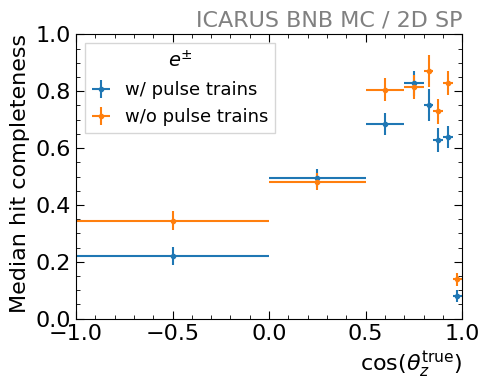

In [95]:
fig, ax = plt.subplots(figsize=(5, 4), ncols=1, layout='tight')

# parameters
Var = 'hitcomp' 
VarName = 'Median hit completeness'
XVar = 'dirztruth'
XVar_Binned = 'dirztruth_binned'
XVarName = 'cos($\\theta^\\mathrm{true}_z$)'
PDGPrintName = 'e'
PDGName = '$e^{\pm}$'

# mask per particle?
Mask = (abs(Data_1D.pdg) == 11) & (Data_1D.startendenergy > 0.05)
Mask_NPP =  (abs(Data_2D.pdg) == 11) & (Data_2D.startendenergy > 0.05)

DataToPlot = Data_1D[Mask].copy()
DataToPlot_NPP = Data_2D[Mask_NPP].copy()

# binned variable
width = 0.2
bins = numpy.array([-1, 0, 0.5, 0.7, 0.8, 0.85, 0.9, 0.95, 1]) # Z
xAngle = numpy.array((bins[:-1] + bins[1:]) / 2.)
xErrors = [[(bins[i]+bins[i+1])/2 - bins[i], bins[i+1] - (bins[i]+bins[i+1])/2] for i in range(len(bins)-1)] # L and R errors
DataToPlot[XVar_Binned] = pandas.cut(DataToPlot[XVar], bins=bins, right=False)
DataToPlot_NPP[XVar_Binned] = pandas.cut(DataToPlot_NPP[XVar], bins=bins, right=False)

#ax2 = ax.twinx()
#y, bins, _ = ax2.hist(Data[XVar], bins=bins, density=True, zorder=-3, alpha=0.2, fc='gray')
#x = (bins[:-1] + bins[1:]) / 2.
#ax2.errorbar(x, y, yerr=numpy.array(y))

y = DataToPlot.groupby(XVar_Binned, observed=False)[Var].median()
ystd = DataToPlot.groupby(XVar_Binned, observed=False)[Var].std()
n = DataToPlot.groupby(XVar_Binned, observed=False)[Var].count()
yerr = 1.235 * ystd / numpy.sqrt(n)
ax.errorbar(xAngle, y, xerr=numpy.array(xErrors).T, yerr=yerr, ls='', marker='.', label='w/ pulse trains')

y_NPP = DataToPlot_NPP.groupby(XVar_Binned, observed=False)[Var].median()
ystd_NPP = DataToPlot_NPP.groupby(XVar_Binned, observed=False)[Var].std()
n_NPP = DataToPlot_NPP.groupby(XVar_Binned, observed=False)[Var].count()
yerr_NPP = 1.235 * ystd_NPP / numpy.sqrt(n_NPP)
ax.errorbar(xAngle, y_NPP, xerr=numpy.array(xErrors).T, yerr=yerr_NPP, ls='', marker='.', label='w/o pulse trains')

# labels
ax.set_title("ICARUS BNB MC / 2D SP", fontsize=16, loc='right', color='gray')
ax.set_xlabel(XVarName, fontsize=16, loc='right')
ax.set_ylabel(VarName, fontsize=16, loc='top')
leg = ax.legend(frameon=True, fancybox=False, fontsize=13., ncol=1, loc='upper left', handlelength=1, columnspacing=1, title=PDGName)
leg.get_title().set_fontsize('14')
                
# ticks
ax.tick_params(labelsize=16, length=6, direction='in', right=True, top=True)
ax.tick_params(which='minor', length=3, direction='in', right=True, top=True)
# ax.ticklabel_format(style='scientific', axis='y', scilimits=(0,0), useMathText=True)
# ax.yaxis.offsetText.set_fontsize(13)
ax.minorticks_on()
ax.set_xlim(bins[0], bins[-1])
ax.set_ylim(0., 1)
#ax.set_yscale('log')

plt.show()
fig.savefig(f"Plots/V10Validation_NuE_{Var}_{XVar}_{PDGPrintName}.png", bbox_inches='tight', dpi=300)

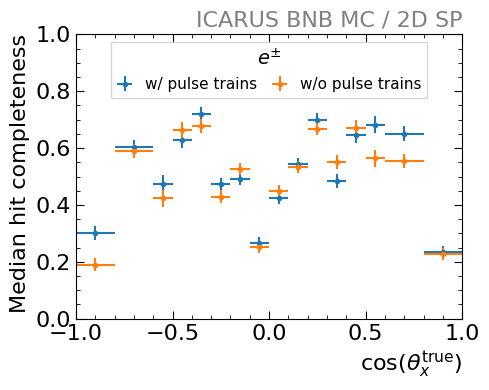

In [110]:
fig, ax = plt.subplots(figsize=(5, 4), ncols=1, layout='tight')

# parameters
Var = 'hitcomp'
VarName = 'Median hit completeness'
XVar = 'dirxtruth'
XVar_Binned = 'dirxtruth_binned'
XVarName = 'cos($\\theta^\\mathrm{true}_x$)'
PDGPrintName = 'e'
PDGName = '$e^{\pm}$'

# mask per particle?
Mask = (abs(Data.pdg) == 11) & (Data.startendenergy > 0.05)
Mask_NPP =  (abs(Data_NPP.pdg) == 11) & (Data_NPP.startendenergy > 0.05)

DataToPlot = Data[Mask].copy()
DataToPlot_NPP = Data_NPP[Mask_NPP].copy()

# binned variable
width = 0.2
bins = numpy.array([-1, -0.8, -0.6, -0.5, -0.4, -0.3, -0.2, -0.1, 0., 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.8, 1]) # X
xAngle = numpy.array((bins[:-1] + bins[1:]) / 2.)
xErrors = [[(bins[i]+bins[i+1])/2 - bins[i], bins[i+1] - (bins[i]+bins[i+1])/2] for i in range(len(bins)-1)] # L and R errors
DataToPlot[XVar_Binned] = pandas.cut(DataToPlot[XVar], bins=bins, right=False)
DataToPlot_NPP[XVar_Binned] = pandas.cut(DataToPlot_NPP[XVar], bins=bins, right=False)

#ax2 = ax.twinx()
#y, bins, _ = ax2.hist(Data[XVar], bins=bins, density=True, zorder=-3, alpha=0.2, fc='gray')
#x = (bins[:-1] + bins[1:]) / 2.
#ax2.errorbar(x, y, yerr=numpy.array(y))

y = DataToPlot.groupby(XVar_Binned, observed=False)[Var].median()
ystd = DataToPlot.groupby(XVar_Binned, observed=False)[Var].std()
n = DataToPlot.groupby(XVar_Binned, observed=False)[Var].count()
yerr = 1.235 * ystd / numpy.sqrt(n)
ax.errorbar(xAngle, y, xerr=numpy.array(xErrors).T, yerr=yerr, ls='', marker='.', label='w/ pulse trains')

y_NPP = DataToPlot_NPP.groupby(XVar_Binned, observed=False)[Var].median()
ystd_NPP = DataToPlot_NPP.groupby(XVar_Binned, observed=False)[Var].std()
n_NPP = DataToPlot_NPP.groupby(XVar_Binned, observed=False)[Var].count()
yerr_NPP = 1.235 * ystd_NPP / numpy.sqrt(n_NPP)
ax.errorbar(xAngle, y_NPP, xerr=numpy.array(xErrors).T, yerr=yerr_NPP, ls='', marker='.', label='w/o pulse trains')

# labels
ax.set_title("ICARUS BNB MC / 2D SP", fontsize=16, loc='right', color='gray')
ax.set_xlabel(XVarName, fontsize=16, loc='right')
ax.set_ylabel(VarName, fontsize=16, loc='top')
leg = ax.legend(frameon=True, fancybox=False, fontsize=11., ncol=2, loc='upper center', handlelength=1, columnspacing=1, title=PDGName)
leg.get_title().set_fontsize('14')
                
# ticks
ax.tick_params(labelsize=16, length=6, direction='in', right=True, top=True)
ax.tick_params(which='minor', length=3, direction='in', right=True, top=True)
# ax.ticklabel_format(style='scientific', axis='y', scilimits=(0,0), useMathText=True)
# ax.yaxis.offsetText.set_fontsize(13)
ax.minorticks_on()
ax.set_xlim(bins[0], bins[-1])
ax.set_ylim(0., 1)
#ax.set_yscale('log')

plt.show()
fig.savefig(f"Plots/V10Validation_NuE_{Var}_{XVar}_{PDGPrintName}.png", bbox_inches='tight', dpi=300)

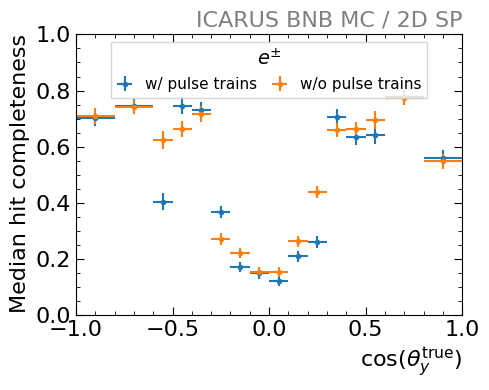

In [81]:
fig, ax = plt.subplots(figsize=(5, 4), ncols=1, layout='tight')

# parameters
Var = 'hitcomp'
VarName = 'Median hit completeness'
XVar = 'dirytruth'
XVar_Binned = 'dirytruth_binned'
XVarName = 'cos($\\theta^\\mathrm{true}_y$)'
PDGPrintName = 'e'
PDGName = '$e^{\pm}$'

# mask per particle?
Mask = (abs(Data.pdg) == 11) & (Data.startendenergy > 0.05)
Mask_NPP =  (abs(Data_NPP.pdg) == 11) & (Data_NPP.startendenergy > 0.05)

DataToPlot = Data[Mask].copy()
DataToPlot_NPP = Data_NPP[Mask_NPP].copy()

# binned variable
width = 0.2
bins = numpy.array([-1, -0.8, -0.6, -0.5, -0.4, -0.3, -0.2, -0.1, 0., 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.8, 1]) # X
xAngle = numpy.array((bins[:-1] + bins[1:]) / 2.)
xErrors = [[(bins[i]+bins[i+1])/2 - bins[i], bins[i+1] - (bins[i]+bins[i+1])/2] for i in range(len(bins)-1)] # L and R errors
DataToPlot[XVar_Binned] = pandas.cut(DataToPlot[XVar], bins=bins, right=False)
DataToPlot_NPP[XVar_Binned] = pandas.cut(DataToPlot_NPP[XVar], bins=bins, right=False)

#ax2 = ax.twinx()
#y, bins, _ = ax2.hist(Data[XVar], bins=bins, density=True, zorder=-3, alpha=0.2, fc='gray')
#x = (bins[:-1] + bins[1:]) / 2.
#ax2.errorbar(x, y, yerr=numpy.array(y))

y = DataToPlot.groupby(XVar_Binned, observed=False)[Var].median()
ystd = DataToPlot.groupby(XVar_Binned, observed=False)[Var].std()
n = DataToPlot.groupby(XVar_Binned, observed=False)[Var].count()
yerr = 1.235 * ystd / numpy.sqrt(n)
ax.errorbar(xAngle, y, xerr=numpy.array(xErrors).T, yerr=yerr, ls='', marker='.', label='w/ pulse trains')

y_NPP = DataToPlot_NPP.groupby(XVar_Binned, observed=False)[Var].median()
ystd_NPP = DataToPlot_NPP.groupby(XVar_Binned, observed=False)[Var].std()
n_NPP = DataToPlot_NPP.groupby(XVar_Binned, observed=False)[Var].count()
yerr_NPP = 1.235 * ystd_NPP / numpy.sqrt(n_NPP)
ax.errorbar(xAngle, y_NPP, xerr=numpy.array(xErrors).T, yerr=yerr_NPP, ls='', marker='.', label='w/o pulse trains')

# labels
ax.set_title("ICARUS BNB MC / 2D SP", fontsize=16, loc='right', color='gray')
ax.set_xlabel(XVarName, fontsize=16, loc='right')
ax.set_ylabel(VarName, fontsize=16, loc='top')
leg = ax.legend(frameon=True, fancybox=False, fontsize=11., ncol=2, loc='upper center', handlelength=1, columnspacing=1, title=PDGName)
leg.get_title().set_fontsize('14')
                
# ticks
ax.tick_params(labelsize=16, length=6, direction='in', right=True, top=True)
ax.tick_params(which='minor', length=3, direction='in', right=True, top=True)
# ax.ticklabel_format(style='scientific', axis='y', scilimits=(0,0), useMathText=True)
# ax.yaxis.offsetText.set_fontsize(13)
ax.minorticks_on()
ax.set_xlim(bins[0], bins[-1])
ax.set_ylim(0., 1.)
#ax.set_yscale('log')

plt.show()
fig.savefig(f"Plots/V10Validation_NuE_{Var}_{XVar}_{PDGPrintName}.png", bbox_inches='tight', dpi=300)

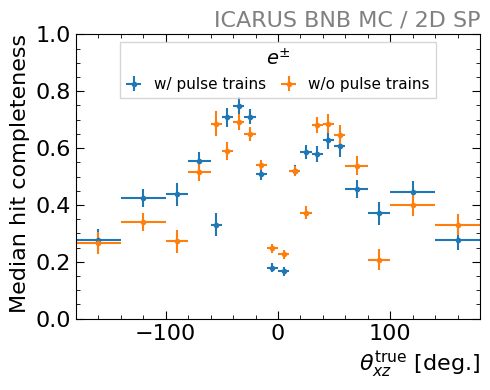

In [86]:
fig, ax = plt.subplots(figsize=(5, 4), ncols=1, layout='tight')

# parameters
Var = 'hitcomp'
VarName = 'Median hit completeness'
XVar = 'dirxztruth'
XVar_Binned = 'diryztruth_binned'
XVarName = '$\\theta^\\mathrm{true}_{xz}$ [deg.]'
PDGPrintName = 'e'
PDGName = '$e^{\pm}$'

# mask per particle?
Mask = (abs(Data.pdg) == 11) & (Data.startendenergy > 0.05)
Mask_NPP =  (abs(Data_NPP.pdg) == 11) & (Data_NPP.startendenergy > 0.05)

DataToPlot = Data[Mask].copy()
DataToPlot_NPP = Data_NPP[Mask_NPP].copy()

# binned variable
width = 0.2
bins = numpy.array([-180, -140, -100, -80, -60, -50, -40, -30, -20, -10, 0, 10, 20, 30, 40, 50, 60, 80, 100, 140, 180]) # X
xAngle = numpy.array((bins[:-1] + bins[1:]) / 2.)
xErrors = [[(bins[i]+bins[i+1])/2 - bins[i], bins[i+1] - (bins[i]+bins[i+1])/2] for i in range(len(bins)-1)] # L and R errors
DataToPlot[XVar_Binned] = pandas.cut(DataToPlot[XVar], bins=bins, right=False)
DataToPlot_NPP[XVar_Binned] = pandas.cut(DataToPlot_NPP[XVar], bins=bins, right=False)

#ax2 = ax.twinx()
#y, bins, _ = ax2.hist(Data[XVar], bins=bins, density=True, zorder=-3, alpha=0.2, fc='gray')
#x = (bins[:-1] + bins[1:]) / 2.
#ax2.errorbar(x, y, yerr=numpy.array(y))

y = DataToPlot.groupby(XVar_Binned, observed=False)[Var].median()
ystd = DataToPlot.groupby(XVar_Binned, observed=False)[Var].std()
n = DataToPlot.groupby(XVar_Binned, observed=False)[Var].count()
yerr = 1.235 * ystd / numpy.sqrt(n)
ax.errorbar(xAngle, y, xerr=numpy.array(xErrors).T, yerr=yerr, ls='', marker='.', label='w/ pulse trains')

y_NPP = DataToPlot_NPP.groupby(XVar_Binned, observed=False)[Var].median()
ystd_NPP = DataToPlot_NPP.groupby(XVar_Binned, observed=False)[Var].std()
n_NPP = DataToPlot_NPP.groupby(XVar_Binned, observed=False)[Var].count()
yerr_NPP = 1.235 * ystd_NPP / numpy.sqrt(n_NPP)
ax.errorbar(xAngle, y_NPP, xerr=numpy.array(xErrors).T, yerr=yerr_NPP, ls='', marker='.', label='w/o pulse trains')

# labels
ax.set_title("ICARUS BNB MC / 2D SP", fontsize=16, loc='right', color='gray')
ax.set_xlabel(XVarName, fontsize=16, loc='right')
ax.set_ylabel(VarName, fontsize=16, loc='top')
leg = ax.legend(frameon=True, fancybox=False, fontsize=11., ncol=2, loc='upper center', handlelength=1, columnspacing=1, title=PDGName)
leg.get_title().set_fontsize('14')
                
# ticks
ax.tick_params(labelsize=16, length=6, direction='in', right=True, top=True)
ax.tick_params(which='minor', length=3, direction='in', right=True, top=True)
# ax.ticklabel_format(style='scientific', axis='y', scilimits=(0,0), useMathText=True)
# ax.yaxis.offsetText.set_fontsize(13)
ax.minorticks_on()
ax.set_xlim(bins[0], bins[-1])
ax.set_ylim(0., 1.)
#ax.set_yscale('log')

plt.show()
fig.savefig(f"Plots/V10Validation_NuE_{Var}_{XVar}_{PDGPrintName}.png", bbox_inches='tight', dpi=300)

### Number of hits

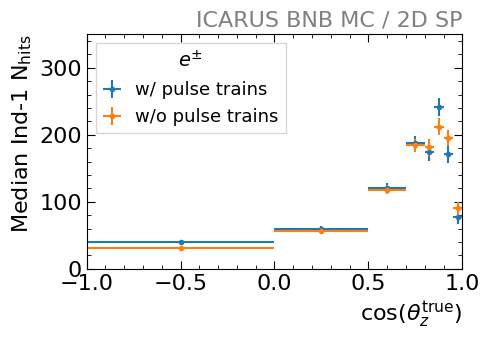

In [90]:
fig, ax = plt.subplots(figsize=(5, 3.5), ncols=1, layout='tight')

# parameters
Var = 'nhits2' 
VarName = 'Median Ind-1 N$_\\mathrm{hits}$'
XVar = 'dirztruth'
XVar_Binned = 'dirztruth_binned'
XVarName = 'cos($\\theta^\\mathrm{true}_z$)'
PDGPrintName = 'e'
PDGName = '$e^{\pm}$'

# mask per particle?
Mask = (abs(Data.pdg) == 11) & (Data.startendenergy > 0.05)
Mask_NPP =  (abs(Data_NPP.pdg) == 11) & (Data_NPP.startendenergy > 0.05)

DataToPlot = Data[Mask].copy()
DataToPlot_NPP = Data_NPP[Mask_NPP].copy()

# binned variable
width = 0.2
bins = numpy.array([-1, 0, 0.5, 0.7, 0.8, 0.85, 0.9, 0.95, 1]) # Z
xAngle = numpy.array((bins[:-1] + bins[1:]) / 2.)
xErrors = [[(bins[i]+bins[i+1])/2 - bins[i], bins[i+1] - (bins[i]+bins[i+1])/2] for i in range(len(bins)-1)] # L and R errors
DataToPlot[XVar_Binned] = pandas.cut(DataToPlot[XVar], bins=bins, right=False)
DataToPlot_NPP[XVar_Binned] = pandas.cut(DataToPlot_NPP[XVar], bins=bins, right=False)

#ax2 = ax.twinx()
#y, bins, _ = ax2.hist(Data[XVar], bins=bins, density=True, zorder=-3, alpha=0.2, fc='gray')
#x = (bins[:-1] + bins[1:]) / 2.
#ax2.errorbar(x, y, yerr=numpy.array(y))

y = DataToPlot.groupby(XVar_Binned, observed=False)[Var].median()
ystd = DataToPlot.groupby(XVar_Binned, observed=False)[Var].std()
n = DataToPlot.groupby(XVar_Binned, observed=False)[Var].count()
yerr = 1.235 * ystd / numpy.sqrt(n)
ax.errorbar(xAngle, y, xerr=numpy.array(xErrors).T, yerr=yerr, ls='', marker='.', label='w/ pulse trains')

y_NPP = DataToPlot_NPP.groupby(XVar_Binned, observed=False)[Var].median()
ystd_NPP = DataToPlot_NPP.groupby(XVar_Binned, observed=False)[Var].std()
n_NPP = DataToPlot_NPP.groupby(XVar_Binned, observed=False)[Var].count()
yerr_NPP = 1.235 * ystd_NPP / numpy.sqrt(n_NPP)
ax.errorbar(xAngle, y_NPP, xerr=numpy.array(xErrors).T, yerr=yerr_NPP, ls='', marker='.', label='w/o pulse trains')

# labels
ax.set_title("ICARUS BNB MC / 2D SP", fontsize=16, loc='right', color='gray')
ax.set_xlabel(XVarName, fontsize=16, loc='right')
ax.set_ylabel(VarName, fontsize=16, loc='top')
leg = ax.legend(frameon=True, fancybox=False, fontsize=13., ncol=1, loc='upper left', handlelength=1, columnspacing=1, title=PDGName)
leg.get_title().set_fontsize('14')
                
# ticks
ax.tick_params(labelsize=16, length=6, direction='in', right=True, top=True)
ax.tick_params(which='minor', length=3, direction='in', right=True, top=True)
# ax.ticklabel_format(style='scientific', axis='y', scilimits=(0,0), useMathText=True)
# ax.yaxis.offsetText.set_fontsize(13)
ax.minorticks_on()
ax.set_xlim(bins[0], bins[-1])
ax.set_ylim(0., 350)
#ax.set_yscale('log')

plt.show()
fig.savefig(f"Plots/V10Validation_NuE_{Var}_{XVar}_{PDGPrintName}.png", bbox_inches='tight', dpi=300)

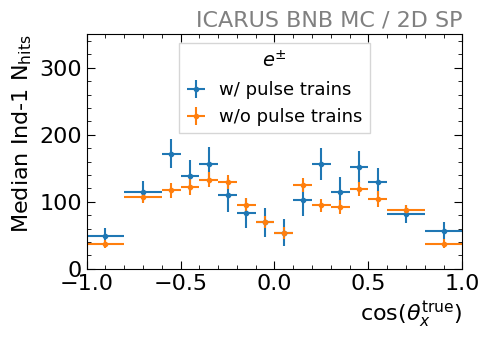

In [101]:
fig, ax = plt.subplots(figsize=(5, 3.5), ncols=1, layout='tight')

# parameters
Var = 'nhits0'
VarName = 'Median Ind-1 N$_\\mathrm{hits}$'
XVar = 'dirxtruth'
XVar_Binned = 'dirxtruth_binned'
XVarName = 'cos($\\theta^\\mathrm{true}_x$)'
PDGPrintName = 'e'
PDGName = '$e^{\pm}$'

# mask per particle?
Mask = (abs(Data.pdg) == 11) & (Data.startendenergy > 0.05)
Mask_NPP =  (abs(Data_NPP.pdg) == 11) & (Data_NPP.startendenergy > 0.05)

DataToPlot = Data[Mask].copy()
DataToPlot_NPP = Data_NPP[Mask_NPP].copy()

# binned variable
width = 0.2
bins = numpy.array([-1, -0.8, -0.6, -0.5, -0.4, -0.3, -0.2, -0.1, 0., 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.8, 1]) # X
xAngle = numpy.array((bins[:-1] + bins[1:]) / 2.)
xErrors = [[(bins[i]+bins[i+1])/2 - bins[i], bins[i+1] - (bins[i]+bins[i+1])/2] for i in range(len(bins)-1)] # L and R errors
DataToPlot[XVar_Binned] = pandas.cut(DataToPlot[XVar], bins=bins, right=False)
DataToPlot_NPP[XVar_Binned] = pandas.cut(DataToPlot_NPP[XVar], bins=bins, right=False)

#ax2 = ax.twinx()
#y, bins, _ = ax2.hist(Data[XVar], bins=bins, density=True, zorder=-3, alpha=0.2, fc='gray')
#x = (bins[:-1] + bins[1:]) / 2.
#ax2.errorbar(x, y, yerr=numpy.array(y))

y = DataToPlot.groupby(XVar_Binned, observed=False)[Var].median()
ystd = DataToPlot.groupby(XVar_Binned, observed=False)[Var].std()
n = DataToPlot.groupby(XVar_Binned, observed=False)[Var].count()
yerr = 1.235 * ystd / numpy.sqrt(n)
ax.errorbar(xAngle, y, xerr=numpy.array(xErrors).T, yerr=yerr, ls='', marker='.', label='w/ pulse trains')

y_NPP = DataToPlot_NPP.groupby(XVar_Binned, observed=False)[Var].median()
ystd_NPP = DataToPlot_NPP.groupby(XVar_Binned, observed=False)[Var].std()
n_NPP = DataToPlot_NPP.groupby(XVar_Binned, observed=False)[Var].count()
yerr_NPP = 1.235 * ystd_NPP / numpy.sqrt(n_NPP)
ax.errorbar(xAngle, y_NPP, xerr=numpy.array(xErrors).T, yerr=yerr_NPP, ls='', marker='.', label='w/o pulse trains')

# labels
ax.set_title("ICARUS BNB MC / 2D SP", fontsize=16, loc='right', color='gray')
ax.set_xlabel(XVarName, fontsize=16, loc='right')
ax.set_ylabel(VarName, fontsize=16, loc='top')
leg = ax.legend(frameon=True, fancybox=False, fontsize=13., ncol=1, loc='upper center', handlelength=1, columnspacing=1, title=PDGName)
leg.get_title().set_fontsize('14')
                
# ticks
ax.tick_params(labelsize=16, length=6, direction='in', right=True, top=True)
ax.tick_params(which='minor', length=3, direction='in', right=True, top=True)
# ax.ticklabel_format(style='scientific', axis='y', scilimits=(0,0), useMathText=True)
# ax.yaxis.offsetText.set_fontsize(13)
ax.minorticks_on()
ax.set_xlim(bins[0], bins[-1])
ax.set_ylim(0., 350)
#ax.set_yscale('log')

plt.show()
fig.savefig(f"Plots/V10Validation_NuE_{Var}_{XVar}_{PDGPrintName}.png", bbox_inches='tight', dpi=300)

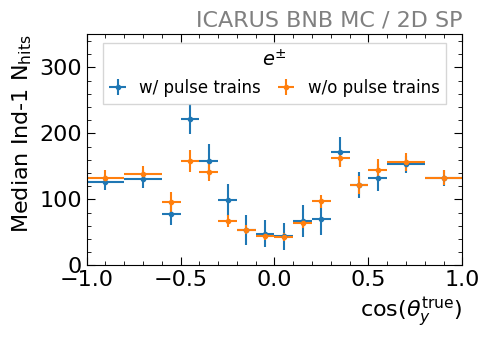

In [102]:
fig, ax = plt.subplots(figsize=(5, 3.5), ncols=1, layout='tight')

# parameters
Var = 'nhits0'
VarName = 'Median Ind-1 N$_\\mathrm{hits}$'
XVar = 'dirytruth'
XVar_Binned = 'dirytruth_binned'
XVarName = 'cos($\\theta^\\mathrm{true}_y$)'
PDGPrintName = 'e'
PDGName = '$e^{\pm}$'

# mask per particle?
Mask = (abs(Data.pdg) == 11) & (Data.startendenergy > 0.05)
Mask_NPP =  (abs(Data_NPP.pdg) == 11) & (Data_NPP.startendenergy > 0.05)

DataToPlot = Data[Mask].copy()
DataToPlot_NPP = Data_NPP[Mask_NPP].copy()

# binned variable
width = 0.2
bins = numpy.array([-1, -0.8, -0.6, -0.5, -0.4, -0.3, -0.2, -0.1, 0., 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.8, 1]) # X
xAngle = numpy.array((bins[:-1] + bins[1:]) / 2.)
xErrors = [[(bins[i]+bins[i+1])/2 - bins[i], bins[i+1] - (bins[i]+bins[i+1])/2] for i in range(len(bins)-1)] # L and R errors
DataToPlot[XVar_Binned] = pandas.cut(DataToPlot[XVar], bins=bins, right=False)
DataToPlot_NPP[XVar_Binned] = pandas.cut(DataToPlot_NPP[XVar], bins=bins, right=False)

#ax2 = ax.twinx()
#y, bins, _ = ax2.hist(Data[XVar], bins=bins, density=True, zorder=-3, alpha=0.2, fc='gray')
#x = (bins[:-1] + bins[1:]) / 2.
#ax2.errorbar(x, y, yerr=numpy.array(y))

y = DataToPlot.groupby(XVar_Binned, observed=False)[Var].median()
ystd = DataToPlot.groupby(XVar_Binned, observed=False)[Var].std()
n = DataToPlot.groupby(XVar_Binned, observed=False)[Var].count()
yerr = 1.235 * ystd / numpy.sqrt(n)
ax.errorbar(xAngle, y, xerr=numpy.array(xErrors).T, yerr=yerr, ls='', marker='.', label='w/ pulse trains')

y_NPP = DataToPlot_NPP.groupby(XVar_Binned, observed=False)[Var].median()
ystd_NPP = DataToPlot_NPP.groupby(XVar_Binned, observed=False)[Var].std()
n_NPP = DataToPlot_NPP.groupby(XVar_Binned, observed=False)[Var].count()
yerr_NPP = 1.235 * ystd_NPP / numpy.sqrt(n_NPP)
ax.errorbar(xAngle, y_NPP, xerr=numpy.array(xErrors).T, yerr=yerr_NPP, ls='', marker='.', label='w/o pulse trains')

# labels
ax.set_title("ICARUS BNB MC / 2D SP", fontsize=16, loc='right', color='gray')
ax.set_xlabel(XVarName, fontsize=16, loc='right')
ax.set_ylabel(VarName, fontsize=16, loc='top')
leg = ax.legend(frameon=True, fancybox=False, fontsize=12., ncol=2, loc='upper center', handlelength=1, columnspacing=1, title=PDGName)
leg.get_title().set_fontsize('14')
                
# ticks
ax.tick_params(labelsize=16, length=6, direction='in', right=True, top=True)
ax.tick_params(which='minor', length=3, direction='in', right=True, top=True)
# ax.ticklabel_format(style='scientific', axis='y', scilimits=(0,0), useMathText=True)
# ax.yaxis.offsetText.set_fontsize(13)
ax.minorticks_on()
ax.set_xlim(bins[0], bins[-1])
ax.set_ylim(0., 350)
#ax.set_yscale('log')

plt.show()
fig.savefig(f"Plots/V10Validation_NuE_{Var}_{XVar}_{PDGPrintName}.png", bbox_inches='tight', dpi=300)

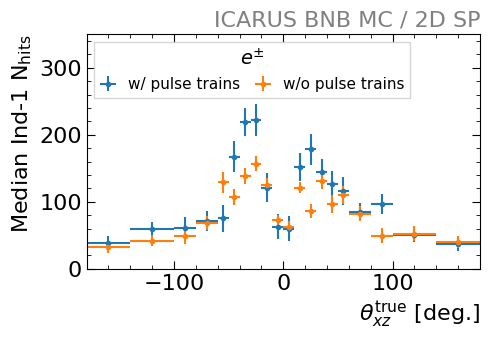

In [103]:
fig, ax = plt.subplots(figsize=(5, 3.5), ncols=1, layout='tight')

# parameters
Var = 'nhits0'
VarName = 'Median Ind-1 N$_\\mathrm{hits}$'
XVar = 'dirxztruth'
XVar_Binned = 'dirxztruth_binned'
XVarName = '$\\theta^\\mathrm{true}_{xz}$ [deg.]'
PDGPrintName = 'e'
PDGName = '$e^{\pm}$'

# mask per particle?
Mask = (abs(Data.pdg) == 11) & (Data.startendenergy > 0.05)
Mask_NPP =  (abs(Data_NPP.pdg) == 11) & (Data_NPP.startendenergy > 0.05)

DataToPlot = Data[Mask].copy()
DataToPlot_NPP = Data_NPP[Mask_NPP].copy()

# binned variable
width = 0.2
bins = numpy.array([-180, -140, -100, -80, -60, -50, -40, -30, -20, -10, 0, 10, 20, 30, 40, 50, 60, 80, 100, 140, 180]) # X
xAngle = numpy.array((bins[:-1] + bins[1:]) / 2.)
xErrors = [[(bins[i]+bins[i+1])/2 - bins[i], bins[i+1] - (bins[i]+bins[i+1])/2] for i in range(len(bins)-1)] # L and R errors
DataToPlot[XVar_Binned] = pandas.cut(DataToPlot[XVar], bins=bins, right=False)
DataToPlot_NPP[XVar_Binned] = pandas.cut(DataToPlot_NPP[XVar], bins=bins, right=False)

#ax2 = ax.twinx()
#y, bins, _ = ax2.hist(Data[XVar], bins=bins, density=True, zorder=-3, alpha=0.2, fc='gray')
#x = (bins[:-1] + bins[1:]) / 2.
#ax2.errorbar(x, y, yerr=numpy.array(y))

y = DataToPlot.groupby(XVar_Binned, observed=False)[Var].median()
ystd = DataToPlot.groupby(XVar_Binned, observed=False)[Var].std()
n = DataToPlot.groupby(XVar_Binned, observed=False)[Var].count()
yerr = 1.235 * ystd / numpy.sqrt(n)
ax.errorbar(xAngle, y, xerr=numpy.array(xErrors).T, yerr=yerr, ls='', marker='.', label='w/ pulse trains')

y_NPP = DataToPlot_NPP.groupby(XVar_Binned, observed=False)[Var].median()
ystd_NPP = DataToPlot_NPP.groupby(XVar_Binned, observed=False)[Var].std()
n_NPP = DataToPlot_NPP.groupby(XVar_Binned, observed=False)[Var].count()
yerr_NPP = 1.235 * ystd_NPP / numpy.sqrt(n_NPP)
ax.errorbar(xAngle, y_NPP, xerr=numpy.array(xErrors).T, yerr=yerr_NPP, ls='', marker='.', label='w/o pulse trains')

# labels
ax.set_title("ICARUS BNB MC / 2D SP", fontsize=16, loc='right', color='gray')
ax.set_xlabel(XVarName, fontsize=16, loc='right')
ax.set_ylabel(VarName, fontsize=16, loc='top')
leg = ax.legend(frameon=True, fancybox=False, fontsize=11., ncol=2, loc='upper left', handlelength=1, columnspacing=1, title=PDGName)
leg.get_title().set_fontsize('14')
                
# ticks
ax.tick_params(labelsize=16, length=6, direction='in', right=True, top=True)
ax.tick_params(which='minor', length=3, direction='in', right=True, top=True)
# ax.ticklabel_format(style='scientific', axis='y', scilimits=(0,0), useMathText=True)
# ax.yaxis.offsetText.set_fontsize(13)
ax.minorticks_on()
ax.set_xlim(bins[0], bins[-1])
ax.set_ylim(0., 350)
#ax.set_yscale('log')

plt.show()
fig.savefig(f"Plots/V10Validation_NuE_{Var}_{XVar}_{PDGPrintName}.png", bbox_inches='tight', dpi=300)

## DNN on/off

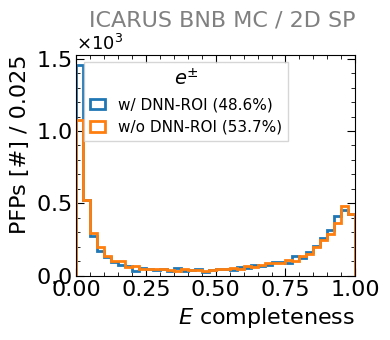

In [125]:
fig, ax = plt.subplots(figsize=(4., 3.5), ncols=1, layout='tight')

Var = 'ecomp'
VarName = '$E$ completeness'
width = 0.025; binning = numpy.arange(0, 1+width, width)

DataToPlot = Data
Mask = (DataToPlot.startendenergy > 0.05) & (abs(DataToPlot.pdg) == 11)
ax.hist(DataToPlot[Mask][Var], bins=binning, histtype='step', lw=2, label='w/ DNN-ROI ' + f'({100*numpy.median(DataToPlot[Mask][Var]):.1f}%)', density=False)

DataToPlot = Data_noDNN
Mask = (DataToPlot.startendenergy > 0.05) & (abs(DataToPlot.pdg) == 11)
ax.hist(DataToPlot[Mask][Var], bins=binning, histtype='step', lw=2, label='w/o DNN-ROI ' + f'({100*numpy.median(DataToPlot[Mask][Var]):.1f}%)', density=False)

# labels
ax.set_title("ICARUS BNB MC / 2D SP", fontsize=16, loc='right', color='gray')
ax.set_xlabel(VarName, fontsize=16, loc='right')
ax.set_ylabel(f"PFPs [#] / {binning[1]-binning[0]:g}", fontsize=16, loc='top')
leg = ax.legend(frameon=True, fancybox=False, fontsize=11., ncol=1, loc='upper left', handlelength=1, columnspacing=1, title='$e^{\pm}$')
leg.get_title().set_fontsize('14')
                
# ticks
ax.tick_params(labelsize=16, length=6, direction='in', right=True, top=True)
ax.tick_params(which='minor', length=3, direction='in', right=True, top=True)
ax.ticklabel_format(style='scientific', axis='y', scilimits=(0,0), useMathText=True)
ax.yaxis.offsetText.set_fontsize(13)
ax.minorticks_on()
ax.set_xlim(binning[0], binning[-1])
#ax.set_yscale('log')

plt.show()
fig.savefig(f"Plots/V10Validation_NuE_DNN-ROI_{Var}.png", bbox_inches='tight', dpi=300)

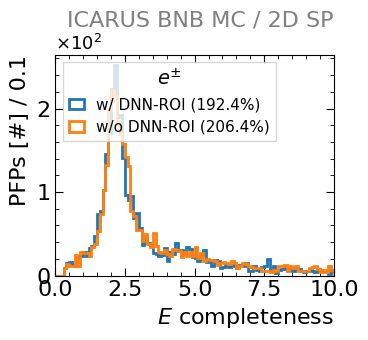

In [133]:
fig, ax = plt.subplots(figsize=(4., 3.5), ncols=1, layout='tight')

Var = 'shwcolldedx'
VarName = '$E$ completeness'
width = 0.1; binning = numpy.arange(0, 10+width, width)

DataToPlot = Data
Mask = (DataToPlot.startendenergy > 0.05) & (abs(DataToPlot.pdg) == 11)
ax.hist(DataToPlot[Mask][Var], bins=binning, histtype='step', lw=2, label='w/ DNN-ROI ' + f'({100*numpy.median(DataToPlot[Mask][Var]):.1f}%)', density=False)

DataToPlot = Data_noDNN
Mask = (DataToPlot.startendenergy > 0.05) & (abs(DataToPlot.pdg) == 11)
ax.hist(DataToPlot[Mask][Var], bins=binning, histtype='step', lw=2, label='w/o DNN-ROI ' + f'({100*numpy.median(DataToPlot[Mask][Var]):.1f}%)', density=False)

# labels
ax.set_title("ICARUS BNB MC / 2D SP", fontsize=16, loc='right', color='gray')
ax.set_xlabel(VarName, fontsize=16, loc='right')
ax.set_ylabel(f"PFPs [#] / {binning[1]-binning[0]:g}", fontsize=16, loc='top')
leg = ax.legend(frameon=True, fancybox=False, fontsize=11., ncol=1, loc='upper left', handlelength=1, columnspacing=1, title='$e^{\pm}$')
leg.get_title().set_fontsize('14')
                
# ticks
ax.tick_params(labelsize=16, length=6, direction='in', right=True, top=True)
ax.tick_params(which='minor', length=3, direction='in', right=True, top=True)
ax.ticklabel_format(style='scientific', axis='y', scilimits=(0,0), useMathText=True)
ax.yaxis.offsetText.set_fontsize(13)
ax.minorticks_on()
ax.set_xlim(binning[0], binning[-1])
#ax.set_yscale('log')

plt.show()

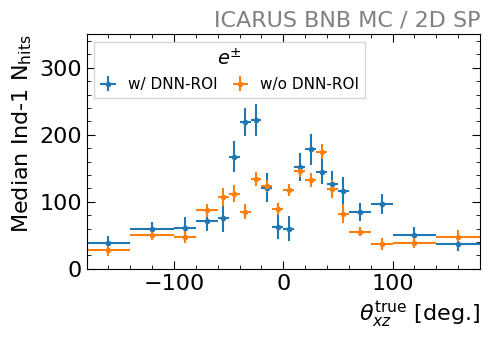

In [127]:
fig, ax = plt.subplots(figsize=(5, 3.5), ncols=1, layout='tight')

# parameters
Var = 'nhits0'
VarName = 'Median Ind-1 N$_\\mathrm{hits}$'
XVar = 'dirxztruth'
XVar_Binned = 'dirxztruth_binned'
XVarName = '$\\theta^\\mathrm{true}_{xz}$ [deg.]'
PDGPrintName = 'e'
PDGName = '$e^{\pm}$'

# mask per particle?
Mask = (abs(Data.pdg) == 11) & (Data.startendenergy > 0.05)
Mask_noDNN =  (abs(Data_noDNN.pdg) == 11) & (Data_noDNN.startendenergy > 0.05)

DataToPlot = Data[Mask].copy()
DataToPlot_noDNN = Data_noDNN[Mask_noDNN].copy()

# binned variable
width = 0.2
bins = numpy.array([-180, -140, -100, -80, -60, -50, -40, -30, -20, -10, 0, 10, 20, 30, 40, 50, 60, 80, 100, 140, 180]) # X
xAngle = numpy.array((bins[:-1] + bins[1:]) / 2.)
xErrors = [[(bins[i]+bins[i+1])/2 - bins[i], bins[i+1] - (bins[i]+bins[i+1])/2] for i in range(len(bins)-1)] # L and R errors
DataToPlot[XVar_Binned] = pandas.cut(DataToPlot[XVar], bins=bins, right=False)
DataToPlot_noDNN[XVar_Binned] = pandas.cut(DataToPlot_noDNN[XVar], bins=bins, right=False)

#ax2 = ax.twinx()
#y, bins, _ = ax2.hist(Data[XVar], bins=bins, density=True, zorder=-3, alpha=0.2, fc='gray')
#x = (bins[:-1] + bins[1:]) / 2.
#ax2.errorbar(x, y, yerr=numpy.array(y))

y = DataToPlot.groupby(XVar_Binned, observed=False)[Var].median()
ystd = DataToPlot.groupby(XVar_Binned, observed=False)[Var].std()
n = DataToPlot.groupby(XVar_Binned, observed=False)[Var].count()
yerr = 1.235 * ystd / numpy.sqrt(n)
ax.errorbar(xAngle, y, xerr=numpy.array(xErrors).T, yerr=yerr, ls='', marker='.', label='w/ DNN-ROI')

y_noDNN = DataToPlot_noDNN.groupby(XVar_Binned, observed=False)[Var].median()
ystd_noDNN = DataToPlot_noDNN.groupby(XVar_Binned, observed=False)[Var].std()
n_noDNN = DataToPlot_noDNN.groupby(XVar_Binned, observed=False)[Var].count()
yerr_noDNN = 1.235 * ystd_noDNN / numpy.sqrt(n_noDNN)
ax.errorbar(xAngle, y_noDNN, xerr=numpy.array(xErrors).T, yerr=yerr_noDNN, ls='', marker='.', label='w/o DNN-ROI')

# labels
ax.set_title("ICARUS BNB MC / 2D SP", fontsize=16, loc='right', color='gray')
ax.set_xlabel(XVarName, fontsize=16, loc='right')
ax.set_ylabel(VarName, fontsize=16, loc='top')
leg = ax.legend(frameon=True, fancybox=False, fontsize=11., ncol=2, loc='upper left', handlelength=1, columnspacing=1, title=PDGName)
leg.get_title().set_fontsize('14')
                
# ticks
ax.tick_params(labelsize=16, length=6, direction='in', right=True, top=True)
ax.tick_params(which='minor', length=3, direction='in', right=True, top=True)
# ax.ticklabel_format(style='scientific', axis='y', scilimits=(0,0), useMathText=True)
# ax.yaxis.offsetText.set_fontsize(13)
ax.minorticks_on()
ax.set_xlim(bins[0], bins[-1])
ax.set_ylim(0., 350)
#ax.set_yscale('log')

plt.show()
fig.savefig(f"Plots/V10Validation_NuE_{Var}_{XVar}_{PDGPrintName}.png", bbox_inches='tight', dpi=300)

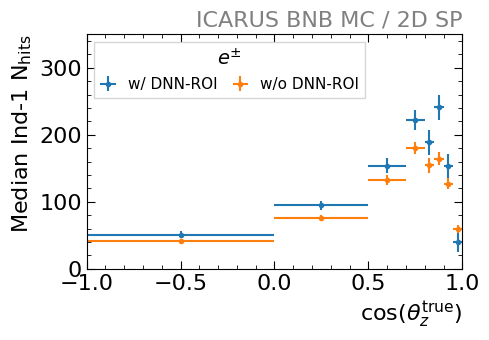

In [128]:
fig, ax = plt.subplots(figsize=(5, 3.5), ncols=1, layout='tight')

# parameters
Var = 'nhits0'
VarName = 'Median Ind-1 N$_\\mathrm{hits}$'
XVar = 'dirztruth'
XVar_Binned = 'dirztruth_binned'
XVarName = 'cos($\\theta^\\mathrm{true}_z$)'
PDGPrintName = 'e'
PDGName = '$e^{\pm}$'

# mask per particle?
Mask = (abs(Data.pdg) == 11) & (Data.startendenergy > 0.05)
Mask_noDNN =  (abs(Data_noDNN.pdg) == 11) & (Data_noDNN.startendenergy > 0.05)

DataToPlot = Data[Mask].copy()
DataToPlot_noDNN = Data_noDNN[Mask_noDNN].copy()

# binned variable
width = 0.2
bins = numpy.array([-1, 0, 0.5, 0.7, 0.8, 0.85, 0.9, 0.95, 1]) # Z
xAngle = numpy.array((bins[:-1] + bins[1:]) / 2.)
xErrors = [[(bins[i]+bins[i+1])/2 - bins[i], bins[i+1] - (bins[i]+bins[i+1])/2] for i in range(len(bins)-1)] # L and R errors
DataToPlot[XVar_Binned] = pandas.cut(DataToPlot[XVar], bins=bins, right=False)
DataToPlot_noDNN[XVar_Binned] = pandas.cut(DataToPlot_noDNN[XVar], bins=bins, right=False)

#ax2 = ax.twinx()
#y, bins, _ = ax2.hist(Data[XVar], bins=bins, density=True, zorder=-3, alpha=0.2, fc='gray')
#x = (bins[:-1] + bins[1:]) / 2.
#ax2.errorbar(x, y, yerr=numpy.array(y))

y = DataToPlot.groupby(XVar_Binned, observed=False)[Var].median()
ystd = DataToPlot.groupby(XVar_Binned, observed=False)[Var].std()
n = DataToPlot.groupby(XVar_Binned, observed=False)[Var].count()
yerr = 1.235 * ystd / numpy.sqrt(n)
ax.errorbar(xAngle, y, xerr=numpy.array(xErrors).T, yerr=yerr, ls='', marker='.', label='w/ DNN-ROI')

y_noDNN = DataToPlot_noDNN.groupby(XVar_Binned, observed=False)[Var].median()
ystd_noDNN = DataToPlot_noDNN.groupby(XVar_Binned, observed=False)[Var].std()
n_noDNN = DataToPlot_noDNN.groupby(XVar_Binned, observed=False)[Var].count()
yerr_noDNN = 1.235 * ystd_noDNN / numpy.sqrt(n_noDNN)
ax.errorbar(xAngle, y_noDNN, xerr=numpy.array(xErrors).T, yerr=yerr_noDNN, ls='', marker='.', label='w/o DNN-ROI')

# labels
ax.set_title("ICARUS BNB MC / 2D SP", fontsize=16, loc='right', color='gray')
ax.set_xlabel(XVarName, fontsize=16, loc='right')
ax.set_ylabel(VarName, fontsize=16, loc='top')
leg = ax.legend(frameon=True, fancybox=False, fontsize=11., ncol=2, loc='upper left', handlelength=1, columnspacing=1, title=PDGName)
leg.get_title().set_fontsize('14')
                
# ticks
ax.tick_params(labelsize=16, length=6, direction='in', right=True, top=True)
ax.tick_params(which='minor', length=3, direction='in', right=True, top=True)
# ax.ticklabel_format(style='scientific', axis='y', scilimits=(0,0), useMathText=True)
# ax.yaxis.offsetText.set_fontsize(13)
ax.minorticks_on()
ax.set_xlim(bins[0], bins[-1])
ax.set_ylim(0., 350)
#ax.set_yscale('log')

plt.show()
fig.savefig(f"Plots/V10Validation_NuE_{Var}_{XVar}_{PDGPrintName}.png", bbox_inches='tight', dpi=300)

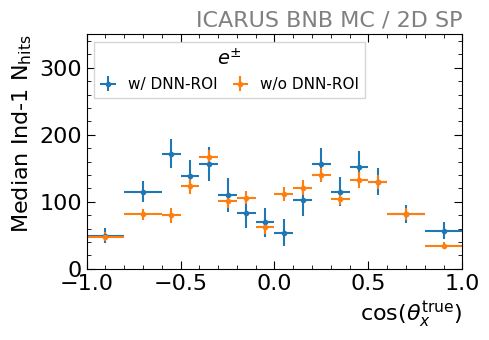

In [129]:
fig, ax = plt.subplots(figsize=(5, 3.5), ncols=1, layout='tight')

# parameters
Var = 'nhits0'
VarName = 'Median Ind-1 N$_\\mathrm{hits}$'
XVar = 'dirxtruth'
XVar_Binned = 'dirxtruth_binned'
XVarName = 'cos($\\theta^\\mathrm{true}_x$)'
PDGPrintName = 'e'
PDGName = '$e^{\pm}$'

# mask per particle?
Mask = (abs(Data.pdg) == 11) & (Data.startendenergy > 0.05)
Mask_noDNN =  (abs(Data_noDNN.pdg) == 11) & (Data_noDNN.startendenergy > 0.05)

DataToPlot = Data[Mask].copy()
DataToPlot_noDNN = Data_noDNN[Mask_noDNN].copy()

# binned variable
width = 0.2
bins = numpy.array([-1, -0.8, -0.6, -0.5, -0.4, -0.3, -0.2, -0.1, 0., 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.8, 1]) # X
xAngle = numpy.array((bins[:-1] + bins[1:]) / 2.)
xErrors = [[(bins[i]+bins[i+1])/2 - bins[i], bins[i+1] - (bins[i]+bins[i+1])/2] for i in range(len(bins)-1)] # L and R errors
DataToPlot[XVar_Binned] = pandas.cut(DataToPlot[XVar], bins=bins, right=False)
DataToPlot_noDNN[XVar_Binned] = pandas.cut(DataToPlot_noDNN[XVar], bins=bins, right=False)

#ax2 = ax.twinx()
#y, bins, _ = ax2.hist(Data[XVar], bins=bins, density=True, zorder=-3, alpha=0.2, fc='gray')
#x = (bins[:-1] + bins[1:]) / 2.
#ax2.errorbar(x, y, yerr=numpy.array(y))

y = DataToPlot.groupby(XVar_Binned, observed=False)[Var].median()
ystd = DataToPlot.groupby(XVar_Binned, observed=False)[Var].std()
n = DataToPlot.groupby(XVar_Binned, observed=False)[Var].count()
yerr = 1.235 * ystd / numpy.sqrt(n)
ax.errorbar(xAngle, y, xerr=numpy.array(xErrors).T, yerr=yerr, ls='', marker='.', label='w/ DNN-ROI')

y_noDNN = DataToPlot_noDNN.groupby(XVar_Binned, observed=False)[Var].median()
ystd_noDNN = DataToPlot_noDNN.groupby(XVar_Binned, observed=False)[Var].std()
n_noDNN = DataToPlot_noDNN.groupby(XVar_Binned, observed=False)[Var].count()
yerr_noDNN = 1.235 * ystd_noDNN / numpy.sqrt(n_noDNN)
ax.errorbar(xAngle, y_noDNN, xerr=numpy.array(xErrors).T, yerr=yerr_noDNN, ls='', marker='.', label='w/o DNN-ROI')

# labels
ax.set_title("ICARUS BNB MC / 2D SP", fontsize=16, loc='right', color='gray')
ax.set_xlabel(XVarName, fontsize=16, loc='right')
ax.set_ylabel(VarName, fontsize=16, loc='top')
leg = ax.legend(frameon=True, fancybox=False, fontsize=11., ncol=2, loc='upper left', handlelength=1, columnspacing=1, title=PDGName)
leg.get_title().set_fontsize('14')
                
# ticks
ax.tick_params(labelsize=16, length=6, direction='in', right=True, top=True)
ax.tick_params(which='minor', length=3, direction='in', right=True, top=True)
# ax.ticklabel_format(style='scientific', axis='y', scilimits=(0,0), useMathText=True)
# ax.yaxis.offsetText.set_fontsize(13)
ax.minorticks_on()
ax.set_xlim(bins[0], bins[-1])
ax.set_ylim(0., 350)
#ax.set_yscale('log')

plt.show()
fig.savefig(f"Plots/V10Validation_NuE_{Var}_{XVar}_{PDGPrintName}.png", bbox_inches='tight', dpi=300)